# Air Pollution & Pediatric Asthma in the Philippines (2013–2022)
### with Davao City as the grounding case study

**Author:** Hertzan D. Alquizola II

**Design:** Ecological, annual, national-level correlation between ambient air pollution
(PM2.5 / PM10) and pediatric asthma prevalence (ages 5–14), 2013–2022, framed around
Davao City lived experience.

**Two data sources:**
1. **Pollution** — Open-Meteo Air Quality API (free, no key). Pulled automatically by this notebook for Davao coordinates.
2. **Asthma** — IHME Global Burden of Disease (GBD), pediatric asthma prevalence for the Philippines. You export this CSV manually (instructions in Step 2) and drop it in `data/raw/gbd/`.

**How to run:** Top to bottom with `Shift + Enter`. Cells marked `# TODO` are the only places you may need to adjust something.


## Step 0 — Imports
Run this first.

In [13]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (11, 5)
sns.set_style('whitegrid')
print("All libraries loaded.")


All libraries loaded.


## Step 1 — Load PM2.5 exposure from disk (GBD SEV)

We no longer pull from the Open-Meteo API. Its air-quality archive only returned ~150 days
for 2022 and **nothing** for 2013–2021, so it can't give a 2013–2022 trend.

Instead we load the GBD **Summary Exposure Value (SEV)** for *Ambient particulate matter
pollution*, Philippines, both sexes, all ages, 2013–2022 — exported from the same site, for
the same country and years as the asthma data, so the two series line up exactly on `year`.

**What SEV is (read this):** SEV is a **0–100 risk-weighted exposure index** — plain English:
how much of the population's *potential* particulate-matter health risk is actually being
realized, where 0 = no exposure and 100 = the worst observed. It is **not** a µg/m³
concentration. Label it as an index, not as µg/m³, in figures and the paper.

In [14]:
# Load PM2.5 exposure (GBD Summary Exposure Value) from disk
# TODO: update this filename only if you re-export the PM2.5 SEV file
POLLUTION_PATH = "../data/raw/gbd/IHME-GBD_2023_DATA-b9d80ff9-1.csv"

pm_raw = pd.read_csv(POLLUTION_PATH)
print("ROWS, COLS:", pm_raw.shape)
print("COLUMNS:", pm_raw.columns.tolist())
for col in ["measure_name", "metric_name", "rei_name", "location_name", "sex_name", "age_name"]:
    if col in pm_raw.columns:
        print(f"{col}:", pm_raw[col].unique().tolist())

# Keep year + value only; rename clearly. pm25_sev = 0-100 exposure index, NOT µg/m³.
pollution = (pm_raw[["year", "val"]]
             .rename(columns={"val": "pm25_sev"})
             .sort_values("year")
             .reset_index(drop=True))

print("\nAnnual PM2.5 exposure (SEV), Philippines:")
print(pollution.to_string(index=False))

ROWS, COLS: (10, 18)
COLUMNS: ['population_group_id', 'population_group_name', 'measure_id', 'measure_name', 'location_id', 'location_name', 'sex_id', 'sex_name', 'age_id', 'age_name', 'rei_id', 'rei_name', 'metric_id', 'metric_name', 'year', 'val', 'upper', 'lower']
measure_name: ['Summary exposure value']
metric_name: ['Rate']
rei_name: ['Ambient particulate matter pollution']
location_name: ['Philippines']
sex_name: ['Both']
age_name: ['All ages']

Annual PM2.5 exposure (SEV), Philippines:
 year  pm25_sev
 2013 16.572773
 2014 17.006369
 2015 17.338225
 2016 17.606074
 2017 18.033844
 2018 18.588073
 2019 19.235267
 2020 19.940303
 2021 21.059683
 2022 22.767373


### Step 1b — Save the pollution series
Keeps a clean processed copy so the rest of the notebook reads from disk. (The old
coverage-flag check is gone — GBD gives a complete value for every year, so there are no
thin-coverage years to warn about.)

In [15]:
pollution.to_csv("../data/processed/ph_pm25_sev_annual.csv", index=False)
print("Saved -> data/processed/ph_pm25_sev_annual.csv")
print(f"Years: {int(pollution['year'].min())}-{int(pollution['year'].max())}  (n={len(pollution)})")

Saved -> data/processed/ph_pm25_sev_annual.csv
Years: 2013-2022  (n=10)


## Step 2 — Load GBD pediatric asthma data

**You export this one manually** (it needs a free IHME login). Do this:

1. Go to **https://vizhub.healthdata.org/gbd-results/**
2. Sign in (free account) when prompted.
3. Set these filters:
   - **GBD Estimate:** Cause of death or injury
   - **Measure:** Prevalence  *(also pull Incidence later if you want)*
   - **Metric:** Rate  *(per 100,000 — comparable across years)*
   - **Cause:** Asthma
   - **Location:** Philippines  *(if a Davao/Region XI option exists, grab it too)*
   - **Age:** the bands covering 5–14 (e.g. `5-9 years`, `10-14 years`)
   - **Sex:** Both
   - **Year:** 2013 to 2022
4. Click **Download** → CSV.
5. Put the file in `data/raw/gbd/` and update the filename below if needed.

The cell prints the column names and unique values first, so we can confirm what you got.


In [16]:
# TODO: update this filename to match what GBD gave you
GBD_PATH = "../data/raw/gbd/IHME-GBD_2023_DATA-373d5433-1.csv"

gbd = pd.read_csv(GBD_PATH)
print("ROWS, COLS:", gbd.shape)
print("\nCOLUMNS:", gbd.columns.tolist())
for col in ["measure_name", "metric_name", "age_name", "sex_name", "cause_name", "location_name"]:
    if col in gbd.columns:
        print(f"\n{col}:", gbd[col].unique())
gbd.head()


ROWS, COLS: (10, 18)

COLUMNS: ['population_group_id', 'population_group_name', 'measure_id', 'measure_name', 'location_id', 'location_name', 'sex_id', 'sex_name', 'age_id', 'age_name', 'cause_id', 'cause_name', 'metric_id', 'metric_name', 'year', 'val', 'upper', 'lower']

measure_name: <StringArray>
['Prevalence']
Length: 1, dtype: str

metric_name: <StringArray>
['Rate']
Length: 1, dtype: str

age_name: <StringArray>
['5-14 years']
Length: 1, dtype: str

sex_name: <StringArray>
['Both']
Length: 1, dtype: str

cause_name: <StringArray>
['Asthma']
Length: 1, dtype: str

location_name: <StringArray>
['Philippines']
Length: 1, dtype: str


,population_group_id,population_group_name,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,1,All Population,5,Prevalence,16,Philippines,3,Both,23,5-14 years,515,Asthma,3,Rate,2013,7448.052646,10958.191559,5037.020741
1,1,All Population,5,Prevalence,16,Philippines,3,Both,23,5-14 years,515,Asthma,3,Rate,2015,7586.918099,11165.273483,5135.727280
2,1,All Population,5,Prevalence,16,Philippines,3,Both,23,5-14 years,515,Asthma,3,Rate,2014,7539.993805,11094.414063,5101.858495
3,1,All Population,5,Prevalence,16,Philippines,3,Both,23,5-14 years,515,Asthma,3,Rate,2018,7580.580354,11110.646489,5122.595499
4,1,All Population,5,Prevalence,16,Philippines,3,Both,23,5-14 years,515,Asthma,3,Rate,2017,7590.920531,11139.248502,5131.457513


### Step 2b — Build the annual pediatric asthma series

The asthma export already comes as a **single `5-14 years` band** (one row per year), so there
is nothing to average across age groups — we just keep those rows. The `groupby(year).mean()`
is left in as a harmless safeguard, so the cell still works if a future export is split into
`5-9` / `10-14`.

In [17]:
# The GBD asthma file uses a single combined pediatric band.
PED_AGES = ["5-14 years"]   # was ["5-9 years", "10-14 years"] -> matched 0 rows

ped = gbd[gbd["age_name"].isin(PED_AGES)].copy()

# Defensive: keep Prevalence + Rate if those columns exist
if "measure_name" in ped.columns:
    ped = ped[ped["measure_name"].str.contains("Prevalence", case=False, na=False)]
if "metric_name" in ped.columns and ped["metric_name"].str.contains("Rate", case=False, na=False).any():
    ped = ped[ped["metric_name"].str.contains("Rate", case=False, na=False)]

# One row per year already; mean() is a no-op here but stays robust if age is ever split.
asthma = ped.groupby("year")["val"].mean().reset_index()
asthma = asthma.rename(columns={"val": "asthma_prev_rate"})

print(f"Rows kept: {len(ped)}  |  Years: {asthma['year'].min()}-{asthma['year'].max()}  (n={len(asthma)})")
print(asthma.to_string(index=False))
asthma.to_csv("../data/processed/ph_pediatric_asthma_annual.csv", index=False)
print("\nSaved -> data/processed/ph_pediatric_asthma_annual.csv")

Rows kept: 10  |  Years: 2013-2022  (n=10)
 year  asthma_prev_rate
 2013       7448.052646
 2014       7539.993805
 2015       7586.918099
 2016       7594.354194
 2017       7590.920531
 2018       7580.580354
 2019       7568.636114
 2020       7560.262268
 2021       7577.496853
 2022       7597.872300

Saved -> data/processed/ph_pediatric_asthma_annual.csv


## Step 3 — Merge pollution + asthma on year

In [18]:
merged = pd.merge(pollution, asthma, on="year", how="inner")
print(merged)
merged.to_csv("../data/processed/merged_annual.csv", index=False)


   year   pm25_sev  asthma_prev_rate
0  2013  16.572773       7448.052646
1  2014  17.006369       7539.993805
2  2015  17.338225       7586.918099
3  2016  17.606074       7594.354194
4  2017  18.033844       7590.920531
5  2018  18.588073       7580.580354
6  2019  19.235267       7568.636114
7  2020  19.940303       7560.262268
8  2021  21.059683       7577.496853
9  2022  22.767373       7597.872300


## Step 4 — Correlation

Pearson (linear) and Spearman (rank/monotonic) for PM2.5 exposure (SEV index) vs pediatric
asthma prevalence. With only 10 yearly points this is **exploratory** — we report the
coefficient AND the p-value AND n, and stay honest that n is small. PM10 is gone: the GBD
exposure export only provides the PM2.5 SEV, so there is a single pollutant series now.

In [19]:
def corr_report(x, y, xlabel):
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]
    pr, pp = stats.pearsonr(x, y)
    sr, sp = stats.spearmanr(x, y)
    print(f"{xlabel} vs pediatric asthma  (n={len(x)})")
    print(f"  Pearson  r = {pr:+.3f}  (p = {pp:.3f})")
    print(f"  Spearman r = {sr:+.3f}  (p = {sp:.3f})\n")
    return {"label": xlabel, "n": len(x),
            "pearson_r": pr, "pearson_p": pp,
            "spearman_r": sr, "spearman_p": sp}

print("=== CORRELATION RESULTS (levels) ===\n")
res_levels = corr_report(merged["pm25_sev"], merged["asthma_prev_rate"],
                         "PM2.5 exposure (SEV index)")

=== CORRELATION RESULTS (levels) ===

PM2.5 exposure (SEV index) vs pediatric asthma  (n=10)
  Pearson  r = +0.470  (p = 0.170)
  Spearman r = +0.394  (p = 0.260)



### Step 4b — Is it real, or just a shared time trend?

Both series move over time (exposure climbs, asthma is basically flat), so a raw correlation
can be driven purely by *time*, not by any real link between the two. The standard check is to
**detrend**: correlate the year-over-year *changes* (first differences) instead of the levels.
If the association survives detrending, it's more than a shared trend; if it collapses, the
level correlation was mostly the clock ticking.

In [20]:
# First differences = year-over-year change; removes the common time trend
d = merged.sort_values("year").copy()
d_pm = d["pm25_sev"].diff()
d_as = d["asthma_prev_rate"].diff()

print("=== CORRELATION RESULTS (detrended / first differences) ===\n")
res_detrended = corr_report(d_pm, d_as, "PM2.5 exposure (SEV index), detrended")

=== CORRELATION RESULTS (detrended / first differences) ===

PM2.5 exposure (SEV index), detrended vs pediatric asthma  (n=9)
  Pearson  r = -0.100  (p = 0.799)
  Spearman r = -0.133  (p = 0.732)



## Step 5 — Figures

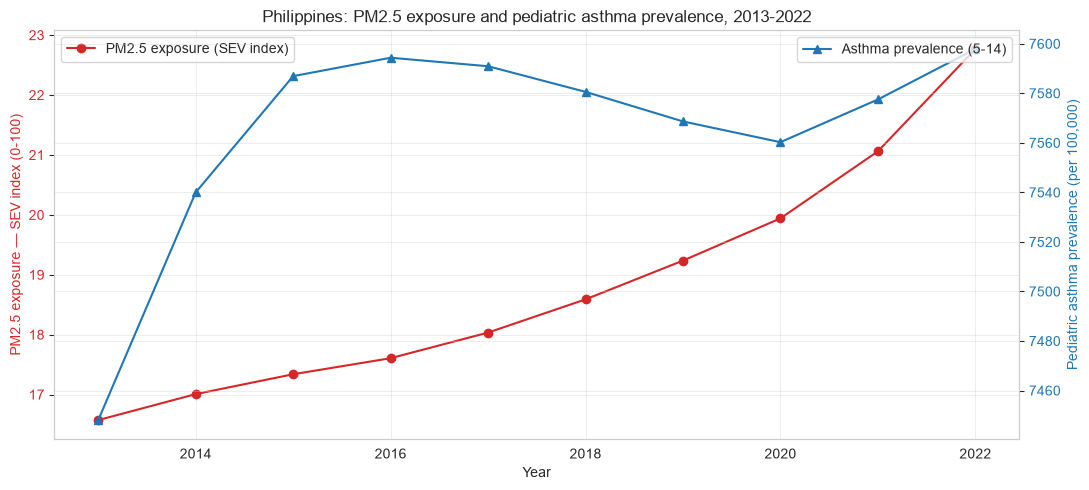

In [21]:
# Figure 1: dual-axis trend over time (PM2.5 SEV index + pediatric asthma rate)
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(merged["year"], merged["pm25_sev"], "o-", color="tab:red",
         label="PM2.5 exposure (SEV index)")
ax1.set_xlabel("Year")
ax1.set_ylabel("PM2.5 exposure — SEV index (0-100)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(merged["year"], merged["asthma_prev_rate"], "^-", color="tab:blue",
         label="Asthma prevalence (5-14)")
ax2.set_ylabel("Pediatric asthma prevalence (per 100,000)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")
ax2.legend(loc="upper right")

plt.title("Philippines: PM2.5 exposure and pediatric asthma prevalence, 2013-2022")
fig.tight_layout()
plt.savefig("../outputs/figures/fig1_trends.png", dpi=300)
plt.show()

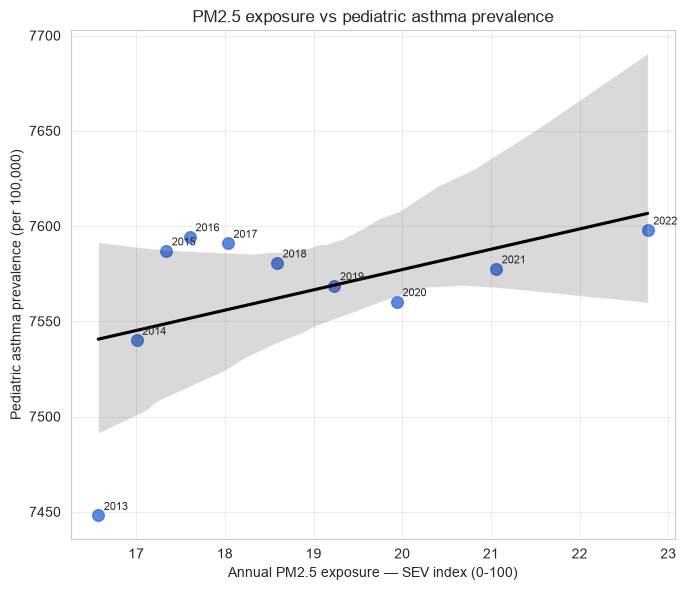

In [22]:
# Figure 2: scatter + fit (PM2.5 SEV index vs asthma)
fig, ax = plt.subplots(figsize=(7, 6))
sns.regplot(x="pm25_sev", y="asthma_prev_rate", data=merged, ax=ax,
            scatter_kws={"s": 70}, line_kws={"color": "black"})
for _, row in merged.iterrows():
    ax.annotate(int(row["year"]), (row["pm25_sev"], row["asthma_prev_rate"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Annual PM2.5 exposure — SEV index (0-100)")
ax.set_ylabel("Pediatric asthma prevalence (per 100,000)")
ax.set_title("PM2.5 exposure vs pediatric asthma prevalence")
fig.tight_layout()
plt.savefig("../outputs/figures/fig2_scatter_pm25.png", dpi=300)
plt.show()

## Step 6 — Save a results table

The merged yearly series plus the correlation statistics, ready for the paper's Results
section.

In [23]:
import os
os.makedirs("../outputs/tables", exist_ok=True)

# (a) the merged yearly series
merged.round(3).to_csv("../outputs/tables/results_annual.csv", index=False)
print("Saved -> outputs/tables/results_annual.csv")

# (b) the correlation statistics (levels + detrended, from Steps 4 and 4b)
stats_rows = [res_levels]
if "res_detrended" in dir():
    stats_rows.append(res_detrended)
corr_table = pd.DataFrame(stats_rows)
corr_table.round(4).to_csv("../outputs/tables/correlation_stats.csv", index=False)
print("Saved -> outputs/tables/correlation_stats.csv")
display(merged.round(3))
display(corr_table.round(4))

Saved -> outputs/tables/results_annual.csv
Saved -> outputs/tables/correlation_stats.csv


,year,pm25_sev,asthma_prev_rate
0,2013,16.573,7448.053
1,2014,17.006,7539.994
2,2015,17.338,7586.918
3,2016,17.606,7594.354
4,2017,18.034,7590.921
5,2018,18.588,7580.580
6,2019,19.235,7568.636
7,2020,19.940,7560.262
8,2021,21.060,7577.497
9,2022,22.767,7597.872


,label,n,pearson_r,pearson_p,spearman_r,spearman_p
0,PM2.5 exposure (SEV index),10,0.4703,0.1701,0.3939,0.2600
1,"PM2.5 exposure (SEV index), detrended",9,-0.0997,0.7986,-0.1333,0.7324


## What's next (after this runs)
- If early years (2013–15) had thin pollution coverage, decide: trim window or note as limitation.
- Pull GBD **Incidence** too, not just Prevalence, for a second outcome measure.
- Add the **WHO national PM2.5** indicator and the **EMB-XI annual report** PM10 as validation
  sources — show your Open-Meteo numbers are in the same ballpark as official figures.
- Write up: correlation ≠ causation; ecological design; annual resolution; modeled pollution.
  State these plainly — they make the paper stronger, not weaker.
